
  turn 1 (original): 2116 correct, 508 incorrect
  turn 2 (original): 2075 correct, 549 incorrect
  turn 3 (original): 2112 correct, 512 incorrect

  turn 1 (ref): 2116 correct, 508 incorrect
  turn 2 (ref): 2075 correct, 549 incorrect
  turn 3 (ref): 2112 correct, 512 incorrect

[saved] logprob_dist_gptoss_humaneval.png


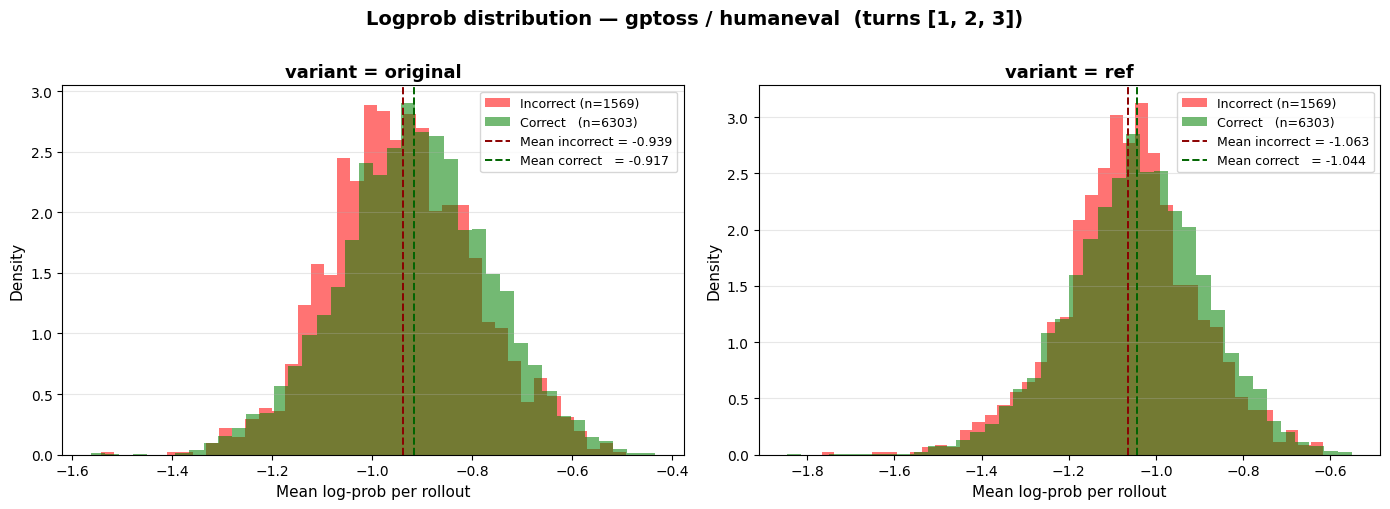

In [1]:
"""
Logprob Analysis: Correct vs Incorrect Rollout Distributions
Usage:
    python logprob_analysis.py --model gptoss --dataset humaneval [--cache_dir ../cache_logprobs]
"""

import pickle
import os
import argparse
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path


# ──────────────────────────────────────────────
# I/O helpers
# ──────────────────────────────────────────────

def load_pkl(cache_dir: str, model: str, dataset: str, turn: int, variant: str) -> list:
    """Load a single pkl file.  variant is 'original' or 'ref'."""
    fname = f"{model}_{dataset}_turn{turn}_{variant}.pkl"
    fpath = os.path.join(cache_dir, fname)
    with open(fpath, "rb") as f:
        return pickle.load(f)


# ──────────────────────────────────────────────
# Metric computation
# ──────────────────────────────────────────────

def compute_metric(logprobs: np.ndarray) -> float:
    """Aggregate per-token logprobs into a single scalar.
    Currently: mean of all token logprobs (i.e. average log-likelihood).
    Swap this function to change the metric globally.
    """
    arr = np.asarray(logprobs, dtype=np.float32)
    return float(np.mean(arr))


# ──────────────────────────────────────────────
# Data extraction
# ──────────────────────────────────────────────

def extract_metrics(records: list) -> tuple[list[float], list[float]]:
    """Return (correct_metrics, incorrect_metrics) from a list of rollout records."""
    correct, incorrect = [], []
    for rec in records:
        lp = rec.get("logprobs")
        if lp is None:
            continue
        metric = compute_metric(lp)
        if rec.get("is_correct"):
            correct.append(metric)
        else:
            incorrect.append(metric)
    return correct, incorrect


def collect_all_turns(
    cache_dir: str, model: str, dataset: str, turns: list[int], variant: str
) -> tuple[list[float], list[float]]:
    """Pool correct / incorrect metrics across all requested turns for one variant."""
    all_correct, all_incorrect = [], []
    for t in turns:
        try:
            records = load_pkl(cache_dir, model, dataset, t, variant)
        except FileNotFoundError as e:
            print(f"  [warn] {e} — skipping")
            continue
        c, inc = extract_metrics(records)
        all_correct.extend(c)
        all_incorrect.extend(inc)
        print(f"  turn {t} ({variant}): {len(c)} correct, {len(inc)} incorrect")
    return all_correct, all_incorrect


# ──────────────────────────────────────────────
# Plotting: distribution (original / ref)
# ──────────────────────────────────────────────

def _plot_distribution_ax(ax, correct: list[float], incorrect: list[float], title: str) -> None:
    """Draw overlapping histograms of correct (green) and incorrect (red) on ax."""
    bins = 40

    if incorrect:
        ax.hist(incorrect, bins=bins, color="red",   alpha=0.55, label=f"Incorrect (n={len(incorrect)})", density=True)
    if correct:
        ax.hist(correct,   bins=bins, color="green", alpha=0.55, label=f"Correct   (n={len(correct)})",   density=True)

    # Vertical mean lines
    if incorrect:
        ax.axvline(np.mean(incorrect), color="darkred",   linestyle="--", linewidth=1.4,
                   label=f"Mean incorrect = {np.mean(incorrect):.3f}")
    if correct:
        ax.axvline(np.mean(correct),   color="darkgreen", linestyle="--", linewidth=1.4,
                   label=f"Mean correct   = {np.mean(correct):.3f}")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Mean log-prob per rollout", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)


def plot_distributions(
    cache_dir: str, model: str, dataset: str, turns: list[int], save: bool = True
) -> None:
    """One figure with two subplots: _original (left) and _ref (right)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Logprob distribution — {model} / {dataset}  (turns {turns})",
        fontsize=14, fontweight="bold", y=1.01,
    )

    for ax, variant in zip(axes, ["original", "ref"]):
        print(f"\nCollecting '{variant}' data …")
        correct, incorrect = collect_all_turns(cache_dir, model, dataset, turns, variant)
        _plot_distribution_ax(
            ax, correct, incorrect,
            title=f"variant = {variant}"
        )

    plt.tight_layout()
    if save:
        out = f"logprob_dist_{model}_{dataset}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"\n[saved] {out}")
    plt.show()


# ──────────────────────────────────────────────
# Plotting: ratio original / ref
# ──────────────────────────────────────────────

def plot_ratio(
    cache_dir: str, model: str, dataset: str, turns: list[int], save: bool = True
) -> None:
    """Plot the ratio of original-metric to ref-metric per rollout (matched by index).

    For each rollout that appears in both files we compute:
        ratio = metric_original / metric_ref
    and separate into correct / incorrect bins.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(
        f"Logprob ratio  (original / ref) — {model} / {dataset}  (turns {turns})",
        fontsize=14, fontweight="bold", y=1.01,
    )

    ratio_correct_all, ratio_incorrect_all = [], []

    for t in turns:
        try:
            orig_records = load_pkl(cache_dir, model, dataset, t, "original")
            ref_records  = load_pkl(cache_dir, model, dataset, t, "ref")
        except FileNotFoundError as e:
            print(f"  [warn] {e} — skipping turn {t}")
            continue

        n = min(len(orig_records), len(ref_records))
        for o, r in zip(orig_records[:n], ref_records[:n]):
            lp_o = o.get("logprobs")
            lp_r = r.get("logprobs")
            if lp_o is None or lp_r is None:
                continue
            m_o = compute_metric(lp_o)
            m_r = compute_metric(lp_r)
            if m_r == 0:
                continue
            ratio = m_o / m_r
            if o.get("is_correct"):
                ratio_correct_all.append(ratio)
            else:
                ratio_incorrect_all.append(ratio)

    bins = 40

    # Left: overlapping histograms
    ax = axes[0]
    if ratio_incorrect_all:
        ax.hist(ratio_incorrect_all, bins=bins, color="red",   alpha=0.55,
                label=f"Incorrect (n={len(ratio_incorrect_all)})", density=True)
    if ratio_correct_all:
        ax.hist(ratio_correct_all,   bins=bins, color="green", alpha=0.55,
                label=f"Correct   (n={len(ratio_correct_all)})",   density=True)
    for vals, col in [(ratio_incorrect_all, "darkred"), (ratio_correct_all, "darkgreen")]:
        if vals:
            ax.axvline(np.mean(vals), color=col, linestyle="--", linewidth=1.4)
    ax.axvline(1.0, color="black", linestyle=":", linewidth=1.2, label="ratio = 1")
    ax.set_title("Overlapping distributions", fontsize=12)
    ax.set_xlabel("Ratio  (orig metric / ref metric)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # Right: box plot comparison
    ax2 = axes[1]
    data_to_plot = []
    labels = []
    colors = []
    if ratio_incorrect_all:
        data_to_plot.append(ratio_incorrect_all)
        labels.append("Incorrect")
        colors.append("red")
    if ratio_correct_all:
        data_to_plot.append(ratio_correct_all)
        labels.append("Correct")
        colors.append("green")

    if data_to_plot:
        bp = ax2.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=False,
                         medianprops=dict(color="black", linewidth=2))
        for patch, col in zip(bp["boxes"], colors):
            patch.set_facecolor(col)
            patch.set_alpha(0.6)
    ax2.axhline(1.0, color="black", linestyle=":", linewidth=1.2, label="ratio = 1")
    ax2.set_title("Box plot of ratios", fontsize=12)
    ax2.set_ylabel("Ratio  (orig / ref)", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    if save:
        out = f"logprob_ratio_{model}_{dataset}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"\n[saved] {out}")
    plt.show()


# ──────────────────────────────────────────────
# CLI entry-point
# ──────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser(description="Logprob distribution analyser")
    parser.add_argument("--model",     default="gptoss",     help="Model name prefix")
    parser.add_argument("--dataset",   default="humaneval",  help="Dataset name")
    parser.add_argument("--cache_dir", default="../cache_logprobs", help="Directory with pkl files")
    parser.add_argument("--turns",     nargs="+", type=int, default=[1, 2, 3])
    parser.add_argument("--no_save",   action="store_true",  help="Don't save figures to disk")
    args = parser.parse_args()

    save = not args.no_save

    print("=== Distribution plots ===")
    plot_distributions(args.cache_dir, args.model, args.dataset, args.turns, save=save)

    print("\n=== Ratio plots ===")
    plot_ratio(args.cache_dir, args.model, args.dataset, args.turns, save=save)

plot_distributions('../cache_logprobs', 'gptoss', 'humaneval',[1,2,3], save=True)


  turn 1 (original): 1514 correct, 1110 incorrect
  turn 2 (original): 1550 correct, 1074 incorrect
  turn 3 (original): 1273 correct, 1351 incorrect

  turn 1 (ref): 1514 correct, 1110 incorrect
  turn 2 (ref): 1550 correct, 1074 incorrect
  turn 3 (ref): 1273 correct, 1351 incorrect

[saved] logprob_dist_qwen1_7b_humaneval.png


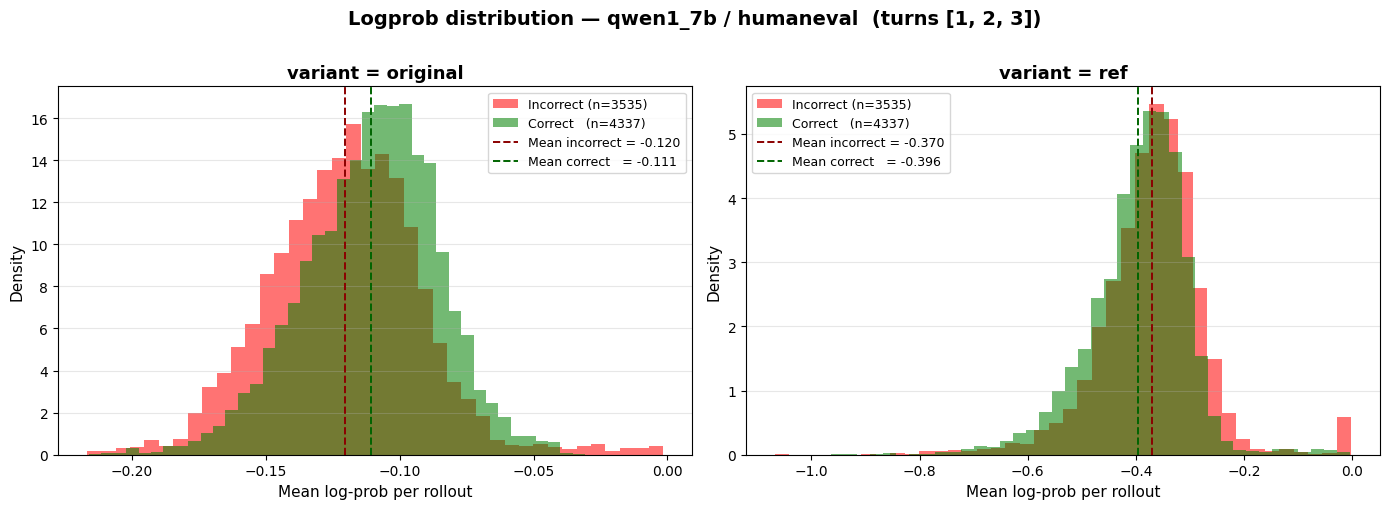

In [2]:
plot_distributions('../cache_logprobs', 'qwen1_7b', 'humaneval',[1,2,3], save=True)

  turn 1 (original): 11831 correct, 4169 incorrect

  turn 1 (ref): 11819 correct, 4142 incorrect

[saved] logprob_dist_gptoss_kodcode.png


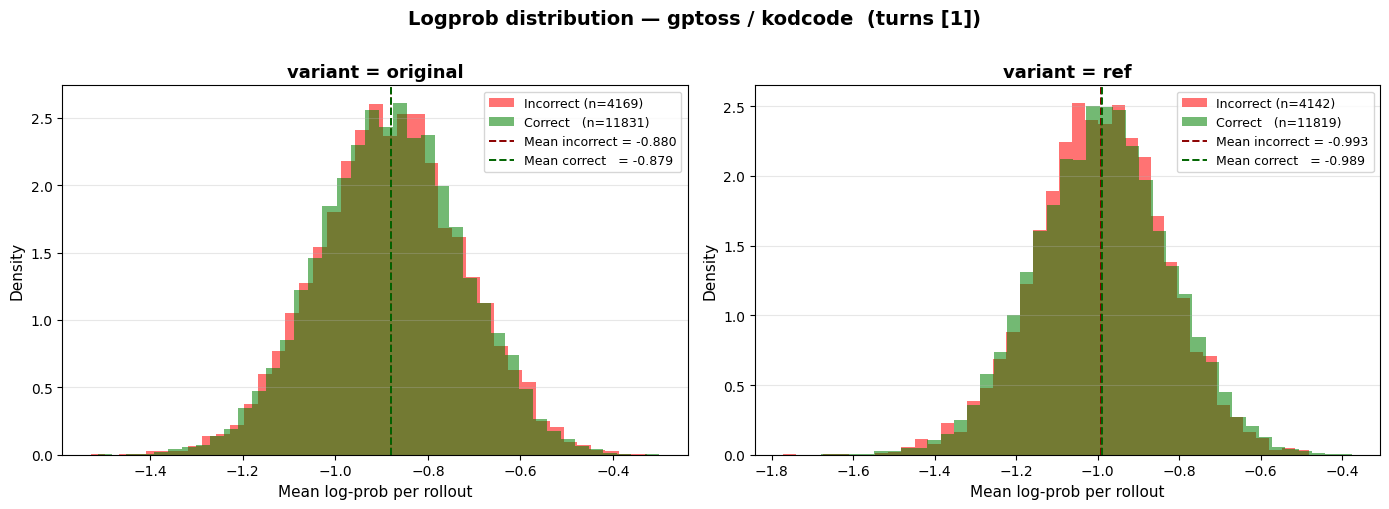

In [6]:
plot_distributions('../cache_logprobs', 'gptoss', 'kodcode',[1], save=True)

  turn 1 (original): 9365 correct, 6635 incorrect
  [warn] [Errno 2] No such file or directory: '../cache_logprobs/qwen1_7b_kodcode_turn2_original.pkl' — skipping
  [warn] [Errno 2] No such file or directory: '../cache_logprobs/qwen1_7b_kodcode_turn3_original.pkl' — skipping

  [warn] [Errno 2] No such file or directory: '../cache_logprobs/qwen1_7b_kodcode_turn1_ref.pkl' — skipping
  [warn] [Errno 2] No such file or directory: '../cache_logprobs/qwen1_7b_kodcode_turn2_ref.pkl' — skipping
  [warn] [Errno 2] No such file or directory: '../cache_logprobs/qwen1_7b_kodcode_turn3_ref.pkl' — skipping


/tmp/ipykernel_788348/2340284833.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)



[saved] logprob_dist_qwen1_7b_kodcode.png


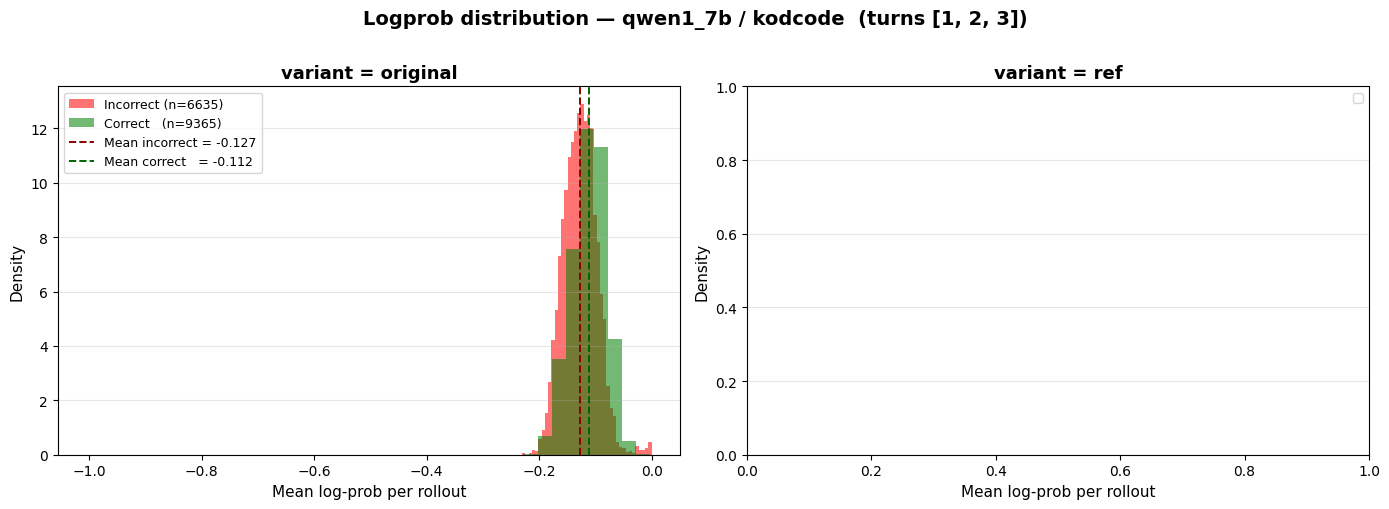

In [7]:
plot_distributions('../cache_logprobs', 'qwen1_7b', 'kodcode',[1,2,3], save=True)